In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

# Plotting options, change to your liking
sc.set_figure_params(figsize=(3, 3), frameon=False)

In [2]:
###Load Data
adata = sc.read_h5ad('/weka/labs/kzhang/kzhang-lab-scratch/blake/HKAv2/HKAv2_intFIB_Subset_12172025.h5ad')
adata

AnnData object with n_obs × n_vars = 10977 × 36588
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'source', 'assay', 'experiment', 'patient', 'specimen', 'condition_level3', 'condition_level2', 'condition_level1', 'condition', 'percent_cortex', 'percent_medulla', 'region_level3', 'region_level2', 'region_level1', 'age_binned', 'sex', 'race', 'KDIGO_stage', 'baseline_eGFR_binned', 'proteinuria_binned', 'A1c_binned', 'albuminuria_binned', 'diabetes_history', 'diabetes_duration', 'hypertension_history', 'hypertension_duration', 'on_RAAS_blockade', 'ckd_stageC', 'location', 'laterality', 'protocol', 'tissue_type_full', 'tissue_type', 'v2.clusters', 'v2.subclass.full', 'v2.subclass.l3', 'v2.subclass.l2', 'v2.subclass.l1', 'v2.state.l2', 'v2.state.l1', 'v2.class', 'v2.structure'
    var: 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'data'

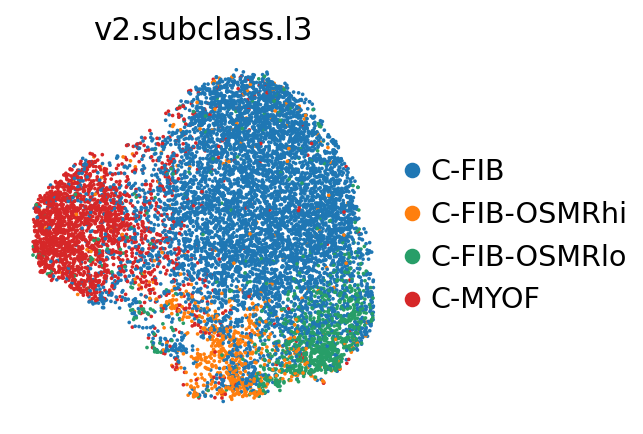

In [4]:
sc.pl.umap(adata, color=["v2.subclass.l3"], ncols=1)

In [5]:
root_celltype = "C-FIB"

sc.pp.neighbors(adata, use_rep="X_pca", n_pcs=20)
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep="X_diffmap")
sc.tl.paga(adata, groups="v2.subclass.l3")
iroot = np.flatnonzero(adata.obs["v2.subclass.l3"] == root_celltype)[0]
adata.uns["iroot"] = iroot
sc.tl.dpt(adata)

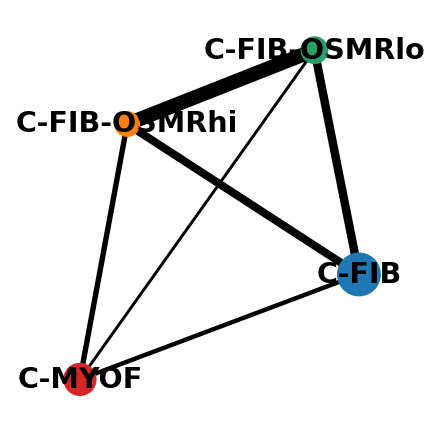

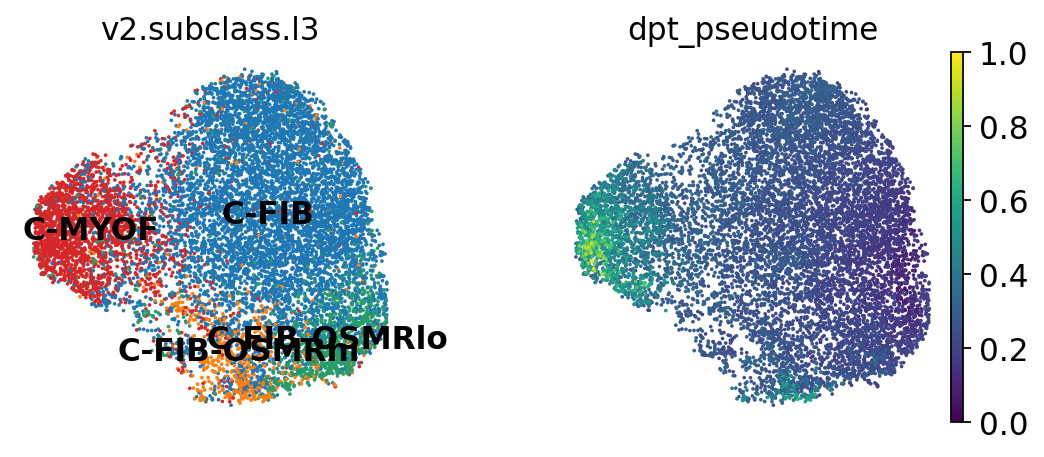

In [6]:
sc.pl.paga(adata, color=["v2.subclass.l3"],
save='PAGA_intFIB_dpt_paga.png')
sc.pl.umap(adata, color=["v2.subclass.l3", "dpt_pseudotime"], legend_loc="on data",
save='PAGA_intFIB_dpt_umap.png')

In [7]:
# read in trajectory (Interstitial_C-MYOF) TF-Gene interactions from scMEGA
tf_gene = pd.read_csv('/weka/blake/Projects/Human_Kidney/Atlas_V2/trajectories/Interstitial_C-MYOF_TF-Gene_Weight_Table.txt', sep='\t')
tf_gene

,source,target,weight
0,ATF3,NRP1,-0.871487
1,ATF3,GTDC1,-0.858020
2,ATF3,DISC1,-0.852347
3,ATF3,PLEKHA6,-0.848571
4,ATF3,HOXA3,-0.838575
...,...,...,...
10495,ZEB1,BAZ2B,-0.752614
10496,ZEB1,BDKRB2,0.752536
10497,ZEB1,HNRNPA1,0.752346
10498,ZEB1,PAPLN,0.752271


In [8]:
dc.mt.ulm(data=adata, net=tf_gene)

In [9]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 10977 × 21
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'source', 'assay', 'experiment', 'patient', 'specimen', 'condition_level3', 'condition_level2', 'condition_level1', 'condition', 'percent_cortex', 'percent_medulla', 'region_level3', 'region_level2', 'region_level1', 'age_binned', 'sex', 'race', 'KDIGO_stage', 'baseline_eGFR_binned', 'proteinuria_binned', 'A1c_binned', 'albuminuria_binned', 'diabetes_history', 'diabetes_duration', 'hypertension_history', 'hypertension_duration', 'on_RAAS_blockade', 'ckd_stageC', 'location', 'laterality', 'protocol', 'tissue_type_full', 'tissue_type', 'v2.clusters', 'v2.subclass.full', 'v2.subclass.l3', 'v2.subclass.l2', 'v2.subclass.l1', 'v2.state.l2', 'v2.state.l1', 'v2.class', 'v2.structure', 'dpt_pseudotime'
    uns: 'v2.subclass.l3_colors', 'neighbors', 'diffmap_evals', 'paga', 'v2.subclass.l3_sizes', 'iroot'
    obsm: 'X_pca', 'X_umap', 'X_diffmap', 'score_ulm', 'padj_ulm'

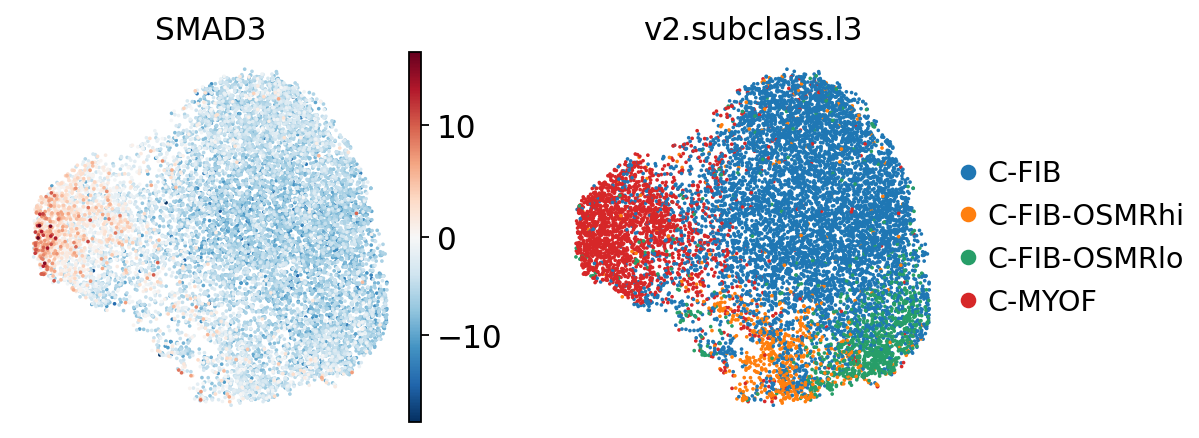

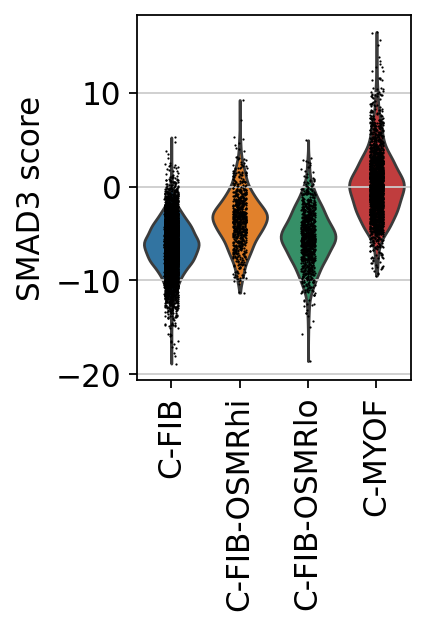

In [10]:
tf = "SMAD3"
sc.pl.umap(score, color=[tf, "v2.subclass.l3"], cmap="RdBu_r", vcenter=0,
save='PAGA_Interstitial_C-MYOF_dpt_umap_SMAD3.png')
sc.pl.violin(score, keys=[tf], groupby="v2.subclass.l3", rotation=90, ylabel=f"{tf} score",
save='PAGA_Interstitial_C-MYOF_dpt_umap_SMAD3_violin.png')

In [11]:
tfs = dc.tl.rankby_order(
    adata=score,
    order="dpt_pseudotime",
    stat="dcor",
)
tfs

,name,stat,pval,padj
0,BACH2,3207.637694,0.0,0.0
1,STAT1,3203.751139,0.0,0.0
2,SOX4,3039.742507,0.0,0.0
3,RUNX2,3029.144361,0.0,0.0
4,HOXA10,3013.481010,0.0,0.0
5,KLF3,3005.245151,0.0,0.0
6,BACH1,2999.909383,0.0,0.0
7,RUNX1,2957.264169,0.0,0.0
8,GLI2,2925.383142,0.0,0.0
9,REST,2878.120963,0.0,0.0


In [12]:
top_tfs = tfs.head(5)["name"].to_list()
top_tfs

['BACH2', 'STAT1', 'SOX4', 'RUNX2', 'HOXA10']

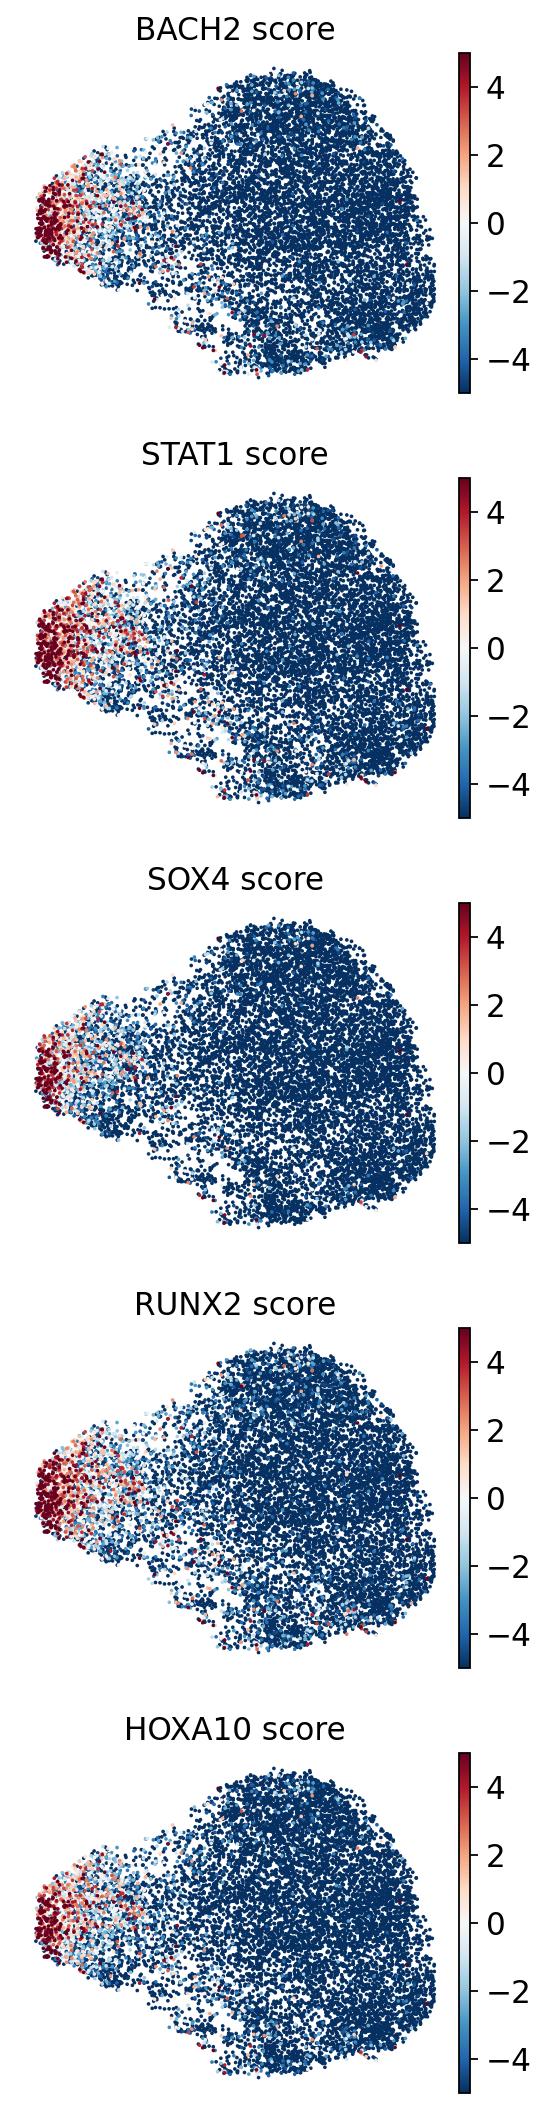

In [13]:
sc.pl.umap(score, color=top_tfs, cmap="RdBu_r", vmin=-5, vmax=5, ncols=1, title=[f"{t} score" for t in top_tfs],
save='PAGA_Interstitial_C-MYOF_dpt_umap_top_tfs.png')

In [14]:
bin_tfs = dc.pp.bin_order(
    adata=score,
    order="dpt_pseudotime",
    names=top_tfs,
    label="v2.subclass.l3",
)
bin_tfs

,name,order,value,label,color
0,BACH2,0.005,-23.015951,C-FIB,#1f77b4
1,BACH2,0.015,-16.569799,C-FIB,#1f77b4
2,BACH2,0.025,-15.895549,C-FIB-OSMRlo,#279e68
3,BACH2,0.035,-17.177164,C-FIB,#1f77b4
4,BACH2,0.035,-12.955927,C-FIB-OSMRlo,#279e68
...,...,...,...,...,...
54880,HOXA10,0.895,4.540028,C-MYOF,#d62728
54881,HOXA10,0.895,3.237691,C-MYOF,#d62728
54882,HOXA10,0.915,3.034181,C-MYOF,#d62728
54883,HOXA10,0.955,-0.235470,C-MYOF,#d62728
